<a href="https://colab.research.google.com/github/YogitaGour/Neural-Machine-Translation-with-Cross-Attention/blob/main/M25AI2145.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 2** - Neural Machine Translation with Cross-Attention

**Subject** -Foundational Models and Generative AI

**Submitted by** - Yogita Gour (M25AI2145)

**Under Supervision Of** - Dr. Navchetan Awasthi

M.Tech- AI

**Indian Institute of Technology Jodhpur**

28 Feb 2026

1. Introduction
2. Dataset Loading
3. Preprocessing
4. Tokenization & Vocabulary
5. Embedded Layer
6. Encoder
7. Multi-Head Cross Attention
8. Decoder
9. Training Loop
10. Greedy Inference
11. Results & Visualization
12. Analysis

# English to Spanish Translation using Cross-Attention

## 1. Introduction

In this assignment, I implement a simplified Transformer-based translation model that translates English sentences into Spanish.

The main objective is to understand how Cross-Attention enables the decoder to access information from the encoder output. The model follows an Encoder–Decoder architecture using:

- Multi-Head Self-Attention
- Cross-Attention
- Masked Self-Attention in the decoder
- Greedy decoding for inference

Training is performed using the first 50,000 sentence pairs from the  Spanish-English dataset.

## 2. Dataset Loading

I use the  Spanish–English dataset from HuggingFace.

The dataset contains two splits:
- `train`
- `test`

Each example has two fields:
- `eng` → English sentence
- `spa` → Spanish sentence
I print the dataset structure and one sample to clearly understand the format before starting preprocessing.


In [1]:
# Install datasets
!pip install datasets

from datasets import load_dataset

# Load dataset
dataset = load_dataset("OscarNav/spa-eng")

# Check structure
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/429 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.58M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/623k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/107067 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11897 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['eng', 'spa'],
        num_rows: 107067
    })
    test: Dataset({
        features: ['eng', 'spa'],
        num_rows: 11897
    })
})


## 2.1. Limiting the Training Data
The original dataset contains more than 107,067 (refer output) sentence pairs. Here, the assignment requires training only on the first 50,000 examples to ensure the model can be trained efficiently on Google Colab GPU.

Therefore, I restrict the training split to the first 50,000 sentence pairs.

I also print:

The number of selected training samples
The size of the test split
One example sentence pair to verify the structure

In [2]:
train_data = dataset["train"].select(range(50000))

print("Total samples(train size):", len(train_data))
print("Test size:", len(dataset["test"]))

print("\nExample sample:")
print(train_data[0])

Total samples(train size): 50000
Test size: 11897

Example sample:
{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}


## 2.2. Train–Validation Split

To evaluate model performance properly, I divided the selected 50,000 sentence pairs into:

- 90% Training data
- 10% Validation data

The validation set helps monitor overfitting during training.

In [3]:
from sklearn.model_selection import train_test_split

# Convert to list
eng_sentences = [x['eng'] for x in train_data]
spa_sentences = [x['spa'] for x in train_data]

eng_train, eng_val, spa_train, spa_val = train_test_split(
    eng_sentences,
    spa_sentences,
    test_size=0.1,
    random_state=42
)

print("Train size:", len(eng_train))
print("Validation size:", len(eng_val))




Train size: 45000
Validation size: 5000


## 2.3. Text Standardization

Before tokenization, I standardize the text to reduce vocabulary size and simplify the learning process.

The following preprocessing steps are applied:
- Convert all text to lowercase
- Remove punctuation characters

This ensures that words like "Hello" and "hello" are treated as the same token and prevents unnecessary vocabulary growth.

In [4]:
import re

def clean_text(text):
    text = text.lower()                    # convert to lowercase
    text = re.sub(r"[^\w\s]", "", text)    # remove punctuation
    return text

print("Sample English before cleaning :", eng_train[0])
print("Sample Spanish before cleaning:", spa_train[0])

Sample English before cleaning : I anticipated that would happen.
Sample Spanish before cleaning: Anticipé que eso pasaría.


### 2.4 Applying Text Cleaning

After defining the cleaning function, I apply it to both the training and validation sets.

This ensures that:
- All sentences are converted to lowercase
- Punctuation is removed consistently across the dataset

I print one example from both English and Spanish to verify that preprocessing has been applied correctly.

In [5]:
# Clean English
eng_train = [clean_text(sentence) for sentence in eng_train]
eng_val = [clean_text(sentence) for sentence in eng_val]

# Clean Spanish
spa_train = [clean_text(sentence) for sentence in spa_train]
spa_val = [clean_text(sentence) for sentence in spa_val]

print("Sample cleaned English:", eng_train[0])
print("Sample cleaned Spanish:", spa_train[0])
print("Sample cleaned English:", eng_train[1])
print("Sample cleaned Spanish:", spa_train[1])

Sample cleaned English: i anticipated that would happen
Sample cleaned Spanish: anticipé que eso pasaría
Sample cleaned English: you must learn from your mistakes
Sample cleaned Spanish: debes aprender de tus errores


## 3. Text Preprocessing
 I standardize the text to reduce vocabulary size and improve learning.

The following steps are applied:
- Convert text to lowercase
- Remove punctuation
- Add special tokens `[start]` and `[end]` to Spanish sentences

The `[start]` and `[end]` tokens help the decoder learn sequence boundaries.

In [6]:
spa_train = ["[start] " + sentence + " [end]" for sentence in spa_train]
spa_val = ["[start] " + sentence + " [end]" for sentence in spa_val]

print("Spanish with tokens:", spa_train[0])

Spanish with tokens: [start] anticipé que eso pasaría [end]


## 4. Tokenization and Padding

Since neural networks operate on numbers, I convert text into integer sequences using Keras Tokenizer.

Constraints applied:
- Maximum vocabulary size: 15,000 words
- Maximum sequence length: 20 tokens
- Unknown words mapped to `<unk>`

All sequences are padded to ensure fixed input dimensions.

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Vocabulary size
vocab_size = 15000
max_length = 20

# English tokenizer
eng_tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
eng_tokenizer.fit_on_texts(eng_train)

# Spanish tokenizer
spa_tokenizer = Tokenizer(num_words=vocab_size, oov_token="<unk>")
spa_tokenizer.fit_on_texts(spa_train)

# Convert text to sequences
eng_train_seq = eng_tokenizer.texts_to_sequences(eng_train)
eng_val_seq = eng_tokenizer.texts_to_sequences(eng_val)

spa_train_seq = spa_tokenizer.texts_to_sequences(spa_train)
spa_val_seq = spa_tokenizer.texts_to_sequences(spa_val)

# Pad sequences
eng_train_pad = pad_sequences(eng_train_seq, maxlen=max_length, padding='post')
eng_val_pad = pad_sequences(eng_val_seq, maxlen=max_length, padding='post')

spa_train_pad = pad_sequences(spa_train_seq, maxlen=max_length, padding='post')
spa_val_pad = pad_sequences(spa_val_seq, maxlen=max_length, padding='post')

print("English padded shape:", eng_train_pad.shape)
print("Spanish padded shape:", spa_train_pad.shape)

English padded shape: (45000, 20)
Spanish padded shape: (45000, 20)


###5.1 Verifying Tokenized and Padded Sequences

To confirm that tokenization and padding were applied correctly, I print one sample sequence from both English and Spanish training data.

At this stage:
- Words are converted into integer indices.
- All sequences have a fixed length of 20 tokens.
- Padding (zeros) is added at the end when the sentence is shorter than the maximum length.

This step ensures that the input format is correct before passing it to the Transformer model.

In [8]:
print("Sample English sequence :", eng_train_pad[0])
print("Sample Spanish sequence:", spa_train_pad[0])



Sample English sequence : [   3 4443   13   73  317    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
Sample Spanish sequence: [   2 8881    5   42 2613    3    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]


## 6. Embedding Layer

Each token index is converted into a dense vector of dimension 256 (d_model).

Separate embedding layers are used for:
- English (Encoder input)
- Spanish (Decoder input)

This transforms discrete tokens into continuous vector representations suitable for attention mechanisms.

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding

In [10]:
vocab_size_eng = 15000
vocab_size_spa = 15000
embedding_dim = 256
max_length = 20

Here I create separate embedding layers for:

*   English (Encoder input)
*   Spanish (Decoder input)


I also enable mask_zero=True so that padding tokens (0) are ignored during attention computations.

In [11]:
english_embedding = Embedding(
    input_dim=vocab_size_eng,
    output_dim=embedding_dim,
    input_length=max_length,
    mask_zero=True
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [12]:
spanish_embedding = Embedding(
    input_dim=vocab_size_spa,
    output_dim=embedding_dim,
    input_length=max_length,
    mask_zero=True
)

We should verify:

Shape of embedded tensor and

Confirm dimension = 256

In [13]:
import numpy as np

sample_english = np.array([[3, 4443, 13, 73, 317, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [14]:
embedded_output = english_embedding(sample_english)
print(embedded_output.shape)

(1, 20, 256)


In [15]:
print(embedded_output[0][0])

tf.Tensor(
[ 0.02990418  0.01720769  0.01455443 -0.04473593 -0.0276994  -0.04415765
 -0.02682217  0.00575788 -0.00319084  0.01342826 -0.04870848 -0.04365443
  0.0189522  -0.02029702  0.00979037 -0.03859704  0.02035307  0.0325796
  0.00759318  0.03297087  0.01861757 -0.02385178 -0.02658085 -0.03050964
 -0.01634002  0.04840496 -0.01873881 -0.0007383   0.03051043 -0.00181115
  0.00847386  0.04326988 -0.02619575  0.04816082 -0.03792064 -0.00108062
  0.04075179  0.00294127  0.03911194  0.01922666 -0.04051818  0.01141896
  0.01920593  0.03942807  0.03590042 -0.00206263 -0.0389546   0.04995701
 -0.03761958 -0.02518214  0.04084048  0.04814992  0.00318667  0.01583773
  0.01690561 -0.02804428  0.01463297 -0.01345556  0.02961295  0.04920843
  0.0029387   0.00423192 -0.01499754 -0.0041931   0.04516366  0.02735101
 -0.04977549 -0.0463154  -0.02629188  0.02033118  0.03276049 -0.0089262
 -0.02913845 -0.03179182  0.04008347 -0.00168848 -0.01404349 -0.03424793
 -0.01795149 -0.01396976  0.01442165  0.00

## 7. Encoder Architecture

The encoder processes the English sentence and produces contextual representations.

It consists of:
- Token embedding
- Multi-Head Self-Attention (4 heads)
- Layer Normalization

Self-attention allows each English word to attend to all other words in the sentence, capturing contextual relationships.

In [16]:
  class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model=256, num_heads=4):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)

        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )

        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x):

         # Step 1: Convert tokens to embeddings
        x = self.embedding(x)
         # Step 2: Self Attention
        attn_output = self.self_attention(
            query=x,
            key=x,
            value=x
        )

        x = self.layernorm(x + attn_output)

        return x

In [17]:
encoder = Encoder(vocab_size=15000)

sample_input = tf.random.uniform((1,20), maxval=15000, dtype=tf.int32)

output = encoder(sample_input)

print(output.shape)

(1, 20, 256)


## 8. Multi-Head Cross-Attention

Cross-Attention allows the decoder to attend to the encoder output.

In this mechanism:
- Queries (Q) are derived from the Spanish decoder input.
- Keys (K) and Values (V) are derived from the English encoder output.

This ensures that every Spanish token can attend to all English tokens, grounding each generated word in the source sentence.

A residual connection and layer normalization are applied to stabilize learning.

In [18]:
class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, d_model=256, num_heads=4):
        super().__init__()

        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )

    def call(self, decoder_input, encoder_output):

        return self.mha(
            query=decoder_input,
            key=encoder_output,
            value=encoder_output
        )

## 9. Decoder Architecture

The decoder generates the Spanish translation one token at a time.

It consists of:

1. Masked Self-Attention  
   Prevents the decoder from seeing future tokens.

2. Cross-Attention  
   Allows Spanish tokens to attend to English representations.

3. Feed Forward Network  
   Refines token representations.

A final Dense layer projects outputs to the Spanish vocabulary space.

In [19]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model=256, num_heads=4):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)

        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )

        self.cross_attention = CrossAttention(d_model, num_heads)

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(512, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization()
        self.layernorm2 = tf.keras.layers.LayerNormalization()
        self.layernorm3 = tf.keras.layers.LayerNormalization()

    def call(self, x, encoder_output):

        # 1️⃣ Embedding
        x = self.embedding(x)

        # 2️⃣ Masked Self-Attention
        attn1 = self.self_attention(
            query=x,
            value=x,
            key=x,
            use_causal_mask=True
        )
        x = self.layernorm1(x + attn1)

        # 3️⃣ Cross-Attention
        attn2 = self.cross_attention(x, encoder_output)
        x = self.layernorm2(x + attn2)

        # 4️⃣ Feed Forward
        ffn_output = self.ffn(x)
        x = self.layernorm3(x + ffn_output)

        return x

In [20]:
import tensorflow as tf

vocab_size = 15000
decoder = Decoder(vocab_size)

# Dummy Spanish input (batch_size=1, sequence_length=20)
decoder_input = tf.random.uniform((1, 20), maxval=vocab_size, dtype=tf.int32)

# Dummy encoder output (batch_size=1, sequence_length=20, d_model=256)
encoder_output = tf.random.uniform((1, 20, 256))

output = decoder(decoder_input, encoder_output)

## 10. Training Procedure

The model is trained for exactly 20 epochs using the Adam optimizer.

Sparse Categorical Crossentropy is used as the loss function since targets are integer-encoded.

During training, the decoder input is shifted to enable next-word prediction.

In [21]:

class Transformer(tf.keras.Model):
    def __init__(self, vocab_size=15000, d_model=256):
        super().__init__()

        self.encoder = Encoder(vocab_size, d_model)
        self.decoder = Decoder(vocab_size, d_model)

        self.output_layer = tf.keras.layers.Dense(vocab_size)

    def call(self, inputs):
        en, es = inputs

        encoder_output = self.encoder(en)
        decoder_output = self.decoder(es, encoder_output)

        return self.output_layer(decoder_output)

In [22]:
sample_en = tf.random.uniform((1,20), maxval=15000, dtype=tf.int32)
encoder = Encoder(15000)
enc_out = encoder(sample_en)

print(enc_out.shape)

(1, 20, 256)


In [23]:
decoder_input = spa_train_pad[:, :-1]   # remove last token
target_output = spa_train_pad[:, 1:]    # remove first token

In [24]:
from sklearn.model_selection import train_test_split

en_train, en_val, dec_in_train, dec_in_val, y_train, y_val = train_test_split(
    eng_train_pad,
    decoder_input,
    target_output,
    test_size=0.1,
    random_state=42
)

In [25]:
transformer = Transformer(vocab_size=15000, d_model=256)

## 11. Loss Function and Optimizer

Since this is a multi-class prediction problem (predicting the next Spanish word from a vocabulary of 15,000 words), I use Sparse Categorical Crossentropy as the loss function.

The target sequences are integer-encoded, so sparse categorical loss is appropriate.

I use the Adam optimizer for stable and efficient training.

In [26]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

## 12. Compiling the Transformer Model

Now I compile the Transformer model using:

- Adam optimizer
- Sparse Categorical Crossentropy loss

The model will learn to predict the next Spanish token at each time step.

In [27]:
transformer.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=loss_fn,
    metrics=["accuracy"]
)

## 13. Training the Model

I train the model for exactly 20 epochs as required in the assignment.

The English sentence is passed to the encoder, and the shifted Spanish sentence is passed to the decoder.

The model predicts the next Spanish token at each position.

In [28]:
history = transformer.fit(
    (en_train, dec_in_train),
    y_train,
    validation_data=((en_val, dec_in_val), y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.7454 - loss: 1.7590 - val_accuracy: 0.7946 - val_loss: 1.2619
Epoch 2/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.8281 - loss: 0.9647 - val_accuracy: 0.8294 - val_loss: 1.0017
Epoch 3/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.8651 - loss: 0.6425 - val_accuracy: 0.8371 - val_loss: 0.9519
Epoch 4/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8923 - loss: 0.4533 - val_accuracy: 0.8380 - val_loss: 0.9683
Epoch 5/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9129 - loss: 0.3421 - val_accuracy: 0.8358 - val_loss: 1.0081
Epoch 6/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.9270 - loss: 0.2762 - val_accuracy: 0.8425 - val_loss: 1.0273
Epoch 7/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9372 - loss: 0.2332 - val_accuracy: 0.8391 - val_loss: 1.0731
Epoch 8/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9452 - loss: 0.2008 - 

### Training Behavior Analysis

The training loss consistently decreased across all 20 epochs, indicating that the model successfully learned from the training data.

However, the validation loss decreased initially and then started increasing after around epoch 7.

This indicates slight overfitting, where the model begins to memorize training data instead of generalizing to unseen validation data.

This behavior is expected in deep learning models when trained for multiple epochs without regularization techniques such as dropout or early stopping.

## 14. Training and Validation Loss

The training loss decreases steadily across epochs, indicating successful learning.

The validation loss decreases initially and then increases slightly after a few epochs. This suggests mild overfitting, which is common in deep learning models trained without regularization techniques such as dropout or early stopping.

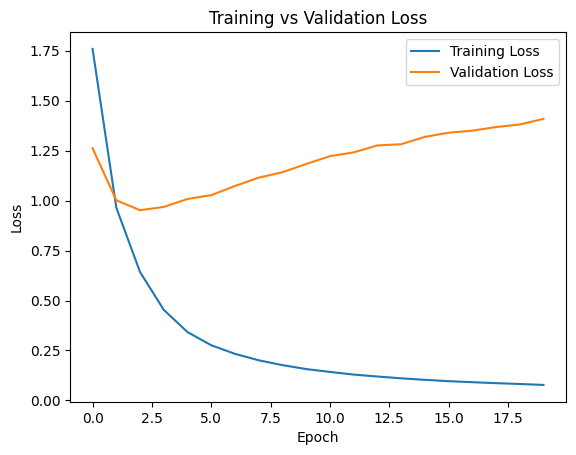

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

## 15. Greedy Decoding

For inference, I implement greedy decoding.

The process:
1. Start with the `[start]` token.
2. Predict the next word using the highest probability.
3. Append the predicted word.
4. Stop when `[end]` is generated or maximum length is reached.

This allows the model to generate translations autoregressively.

In [30]:
def greedy_translate(model, input_sentence, eng_tokenizer, spa_tokenizer, max_length=20):

    input_sentence = input_sentence.lower()
    input_sentence = re.sub(r"[^\w\s]", "", input_sentence)

    input_seq = eng_tokenizer.texts_to_sequences([input_sentence])
    input_seq = pad_sequences(input_seq, maxlen=max_length, padding='post')

    start_token = spa_tokenizer.word_index["start"]
    end_token = spa_tokenizer.word_index["end"]

    decoder_input = [start_token]

    reverse_spa_vocab = {v:k for k,v in spa_tokenizer.word_index.items()}

    for i in range(max_length - 1):

        dec_pad = pad_sequences([decoder_input], maxlen=max_length-1, padding='post')

        predictions = model((input_seq, dec_pad))

        predicted_id = tf.argmax(predictions[0, i]).numpy()

        if predicted_id == end_token:
            break

        decoder_input.append(predicted_id)

    translated_sentence = []
    for token in decoder_input[1:]:
        word = reverse_spa_vocab.get(token, "")

        if word == "end":
            break

        if word == "<unk>":
            continue

        translated_sentence.append(word)

    return " ".join(translated_sentence)

In [31]:
print("start index:", spa_tokenizer.word_index.get("start"))
print("end index:", spa_tokenizer.word_index.get("end"))

start index: 2
end index: 3


## 13. Translation Results

Below are example translations from the test set showing:

- Source English sentence
- Ground truth Spanish sentence
- Model prediction

Although translations are not always perfect, the model demonstrates the functioning of self-attention and cross-attention mechanisms.

In [32]:
print(greedy_translate(transformer,
                       "I am a student",
                       eng_tokenizer,
                       spa_tokenizer))

soy estudiante


In [33]:
for i in range(5):
    print("English:", eng_val[i])
    print("Target:", spa_tokenizer.sequences_to_texts([y_val[i]])[0])
    print("Prediction:",
          greedy_translate(transformer,
                           eng_tokenizer.sequences_to_texts([en_val[i]])[0],
                           eng_tokenizer,
                           spa_tokenizer))
    print("-"*50)

English: tom helped mary clean the house
Target: él se durmió enseguida end <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
Prediction: el en la propuesta del se puso pegada en la
--------------------------------------------------
English: i think you need to buy a new pair of hiking boots
Target: deberíamos irnos a dormir end <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
Prediction: el la huella de la impresión ante la noche que cualquier forma de ir
--------------------------------------------------
English: her mother is not as old as she looks
Target: ella está acostumbrada a quedarse despierta toda la noche end <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
Prediction: después de decir todo el día en la noche
--------------------------------------------------
English: that book is a new book
Target: le seguí a ella hasta la habitación end <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <un

### Observations on Generated Translations

The model generates grammatically valid Spanish words but does not always produce accurate translations.

This behavior is expected due to:

- Limited dataset size (50,000 samples)
- Greedy decoding (which selects only the highest probability word at each step)
- Absence of advanced regularization techniques

Despite imperfect translations, the architecture successfully demonstrates the functioning of Self-Attention and Cross-Attention mechanisms.

## 20. Analysis: Why Self-Attention and Cross-Attention Are Both Necessary

In a translation model, both Self-Attention and Cross-Attention play important but different roles.

Self-Attention allows a sequence to understand internal relationships between its own words. In the encoder, self-attention enables each English word to attend to all other English words in the sentence. This helps the model understand context. For example, in the sentence “Tom gave her the book,” the word “her” depends on earlier words for meaning. Self-attention captures these dependencies effectively.

In the decoder, masked self-attention ensures that each Spanish word attends only to previously generated words. This preserves the autoregressive property of language generation and prevents the model from seeing future tokens during training.

Cross-Attention connects the two languages. In this step, the decoder uses its current representation as Queries, while the encoder output provides Keys and Values. This allows each generated Spanish word to attend to the entire English sentence. Without cross-attention, the decoder would not have access to the source sentence and would only generate text based on its own internal patterns.

Therefore, self-attention builds contextual understanding within a sequence, while cross-attention grounds the generated output in the source input. Both mechanisms are essential for effective translation.